# Возможности OpenCV

- **Загрузка и сохранение изображений** — OpenCV позволяет читать изображения из файлов и сохранять результаты обработки обратно на диск.
- **Преобразование цветовых пространств** — можно переводить изображения между форматами `BGR`, `RGB`, `Grayscale`, `HSV` и другими.
- **Обработка изображений** — библиотека поддерживает фильтрацию, размытие, сглаживание, выделение границ и подавление шума.
- **Геометрические преобразования** — можно выполнять поворот, масштабирование, обрезку, а также аффинные и перспективные преобразования.
- **Обнаружение и распознавание объектов** — OpenCV используется для поиска лиц, объектов, контуров и других элементов на изображении.
- **Работа с видео** — библиотека поддерживает захват видео с камеры или файла, покадровую обработку и отображение видеопотока.

[[[155 161 173]
  [155 161 173]
  [153 161 174]
  ...
  [180 192 208]
  [180 192 208]
  [180 192 208]]

 [[155 161 173]
  [154 160 172]
  [153 161 174]
  ...
  [180 192 208]
  [180 192 208]
  [180 192 208]]

 [[154 160 172]
  [154 160 172]
  [154 162 175]
  ...
  [180 192 208]
  [180 192 208]
  [180 192 208]]

 ...

 [[213 198 179]
  [194 179 160]
  [186 171 152]
  ...
  [220 219 217]
  [221 220 218]
  [253 252 250]]

 [[174 158 143]
  [184 168 153]
  [168 155 138]
  ...
  [250 251 246]
  [250 251 246]
  [252 253 248]]

 [[186 170 157]
  [185 169 154]
  [177 164 148]
  ...
  [253 254 249]
  [252 253 248]
  [253 254 249]]]


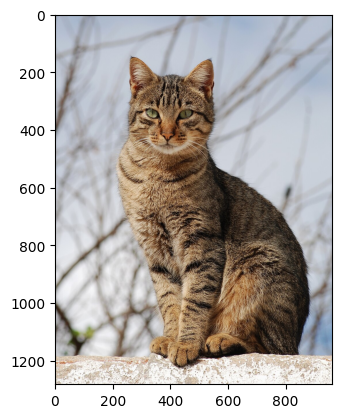

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('C:/VSCode projects/cv_me/images/Cat_November_2010-1a.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img)
plt.imshow(img)
plt.show()

## Координаты пикселей

В OpenCV изображения хранятся в виде массивов NumPy, где каждая ячейка массива представляет собой пиксель.

Особенность NumPy состоит в том, что при обращении к элементам массива сначала указывается координата по оси `Y` (строка), а затем координата по оси `X` (столбец).

Например:

```python
img[y, x]
```

Здесь:

- `y` — номер строки
- `x` — номер столбца

Однако во многих функциях OpenCV координаты задаются в более привычном порядке: сначала `X`, потом `Y`.

То есть:

- в NumPy: `(y, x)`
- в OpenCV: `(x, y)`

Это важно помнить, чтобы не перепутать оси при рисовании, обрезке, выделении областей и других операциях с изображением.

## Форматы изображений: JPG и PNG

### Формат PNG

PNG — это формат изображения без потерь, который сохраняет точные значения цвета и использует сжатие без потерь.

PNG хорошо подходит для изображений, где важна точность цвета, например для логотипов, графиков и иллюстраций.

### Формат JPG

JPG (или JPEG) — это формат изображения с потерями, который использует сжатие для уменьшения размера файла.

Сжатие в формате JPG может приводить к искажению точных значений цвета, даже если исходное изображение было без искажений.

JPG хорошо подходит для фотографий и изображений, где небольшие потери качества не критичны.

# Обработка видеопотока

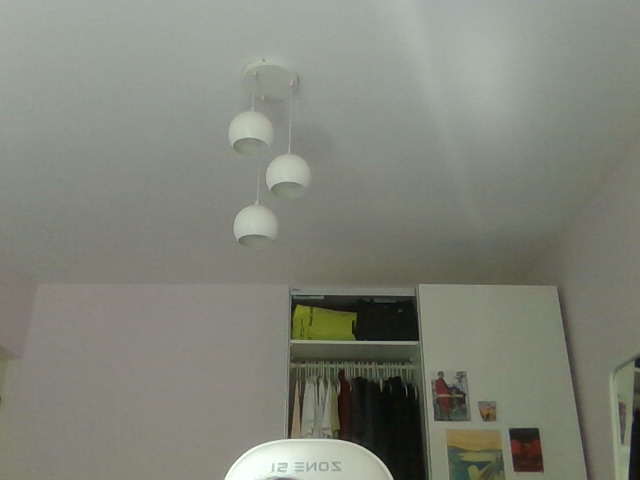

In [3]:
# для jupiter
from IPython.display import display, Image, clear_output
import time

cap = cv2.VideoCapture(0)

try:
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break

        # если хочешь зеркальный эффект
        frame = cv2.flip(frame, 1)

        ok, buffer = cv2.imencode('.jpg', frame)
        if not ok:
            break

        clear_output(wait=True)
        display(Image(data=buffer.tobytes()))

        time.sleep(0.03)  # примерно 30 FPS
except KeyboardInterrupt:
    pass
finally:
    cap.release()

# для .py скриптов
# import cv2

# # Создание объекта для захвата видео
# cap = cv2.VideoCapture(0)  # 0 - индекс веб-камеры

# while cap.isOpened():
#     # Считывание кадров
#     read_ok, frame = cap.read()
    
#     if not read_ok:
#         break
    
#     # Отображение обработанного кадра
#     cv2.imshow('Video Stream', frame)
    
#     # Завершение работы по нажатию клавиши 'Esc'
#     if cv2.waitKey(20) == 27:
#         break

# # Освобождение ресурсов
# cap.release()
# cv2.destroyAllWindows()

## Создание пустого изображения заданного размера

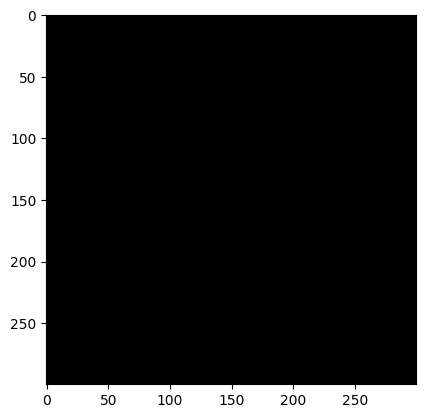

In [4]:
import numpy as np

h, w = 300, 300
image = np.zeros((h, w, 3), dtype=np.uint8)

plt.imshow(image)
plt.show()

## Заполнение изображения цветом

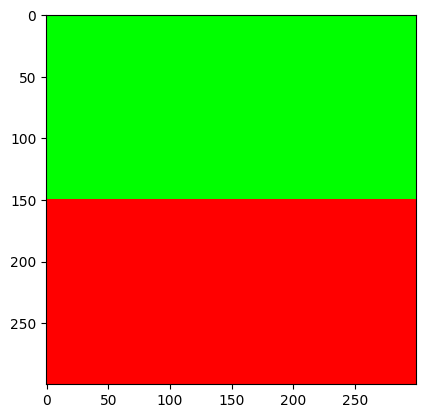

In [5]:
image[:] = [255, 0, 0]
image[:h // 2, :] = [0, 255, 0]
plt.imshow(image)
plt.show()

## Заполнение изображения градиентом

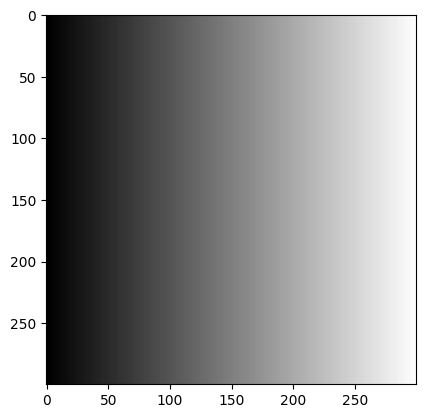

In [6]:
# горизонтальный
image = np.zeros((h, w, 3), dtype=np.uint8)
for x in range(w):
    color = int((x / w) * 255)
    image[:, x] = [color, color, color]
plt.imshow(image)
plt.show()

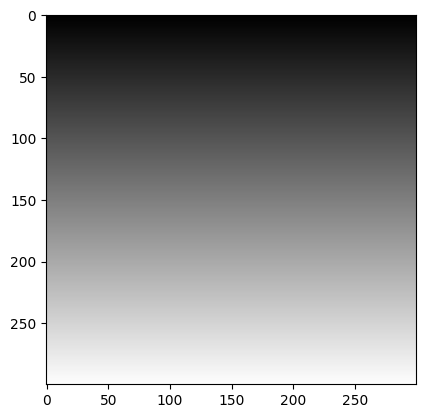

In [7]:
# вертикальный
image = np.zeros((h, w, 3), dtype=np.uint8)
for y in range(h):
    color = int((y / h) * 255)
    image[y, :] = [color, color, color]
plt.imshow(image)
plt.show()

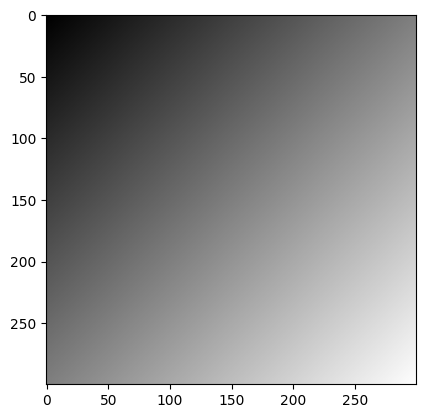

In [8]:
# диагональный
image = np.zeros((h, w, 3), dtype=np.uint8)
for y in range(h):
    for x in range(w):
        color = int(((x + y) / (w + h)) * 255)
        image[y, x] = [color, color, color]
plt.imshow(image)
plt.show()

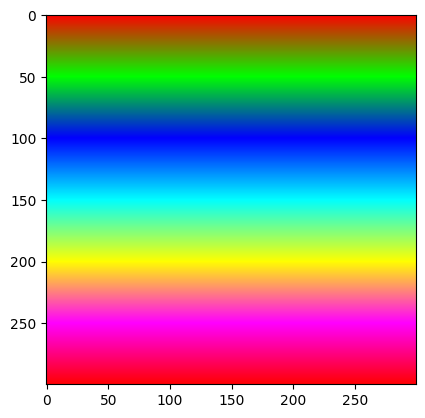

In [9]:
# многоцветный градиент
colors = [
    [255, 0, 0],   
    [0, 255, 0],   
    [0, 0, 255],   
    [0, 255, 255], 
    [255, 255, 0], 
    [255, 0, 255]    
]

image = np.zeros((h, w, 3), dtype=np.uint8)
seg_height = h // len(colors)
for i in range(len(colors)):
    start_color = np.array(colors[i])
    end_color = np.array(colors[(i + 1) % len(colors)])
    for y in range(seg_height):
        color = (start_color * (seg_height - y) + end_color * y) / seg_height
        image[i * seg_height + y, :] = color
plt.imshow(image)
plt.show()

In [10]:
cv2.imwrite('C:/VSCode projects/cv_me/images/output1.png', image)

True

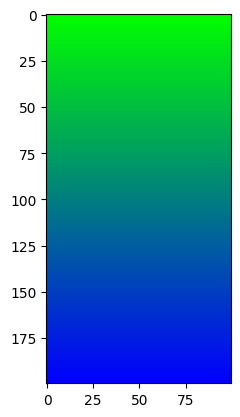

In [11]:
start_color = np.array([0, 255, 0], dtype=np.float32)
end_color = np.array([0, 0, 255], dtype=np.float32)

h = 200
w = 100
image = np.zeros((h, w, 3), dtype=np.uint8)

seg_height = h // 2

for y in range(h):
    t = y / (h - 1)
    color = start_color * (1 - t) + end_color * t
    image[y, :] = color.astype(np.uint8)
plt.imshow(image)
plt.show()

## Фигуры

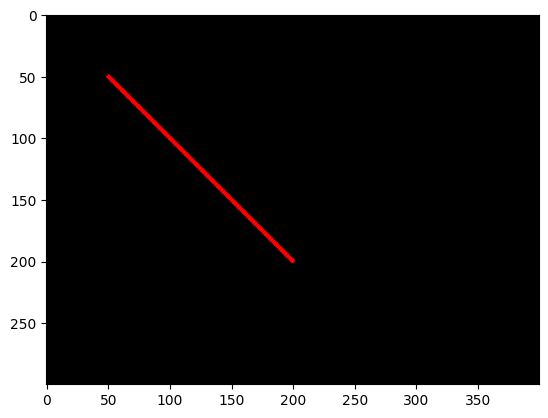

In [13]:
# Линия
image = np.zeros((300, 400, 3), dtype=np.uint8)

start_point = (50, 50)
end_point = (200, 200)
color = (255, 0, 0)  
thickness = 2  

cv2.line(image, start_point, end_point, color, thickness)
plt.imshow(image)
plt.show()

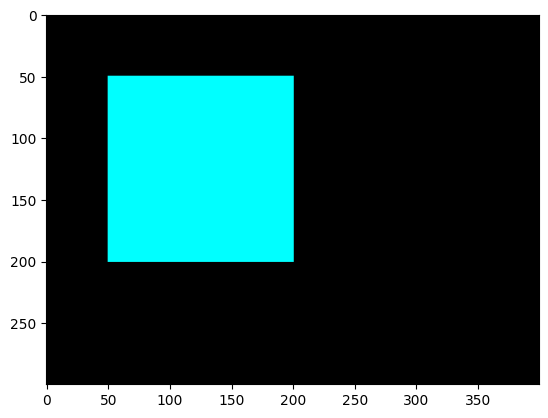

In [14]:
# Прямоугольник
image = np.zeros((300, 400, 3), dtype=np.uint8)

start_point = (50, 50)
end_point = (200, 200)
color = (0, 255, 255)  
thickness = -1

cv2.rectangle(image, start_point, end_point, color, thickness)
plt.imshow(image)
plt.show()

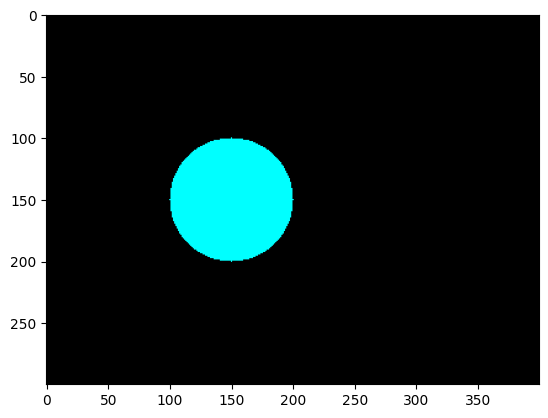

In [15]:
# Круг
image = np.zeros((300, 400, 3), dtype=np.uint8)

center = (150, 150)
radius = 50
color = (0, 255, 255)  
thickness = -1

cv2.circle(image, center, radius, color, thickness)
plt.imshow(image)
plt.show()

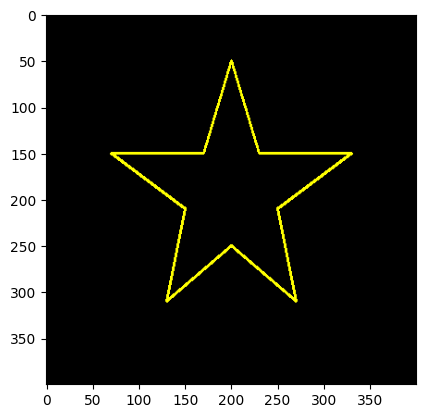

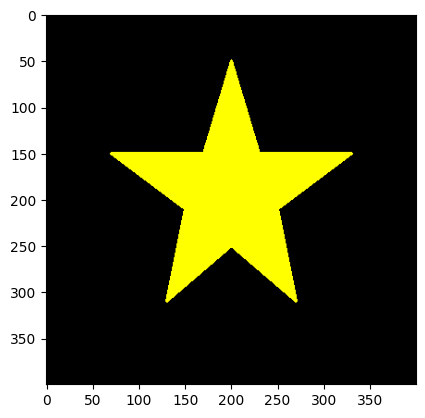

In [16]:
# Полигон
image = np.zeros((400, 400, 3), dtype=np.uint8)

# Координаты вершин звезды
points = np.array([
    [200, 50],   # Верхняя вершина
    [230, 150],  # Правая верхняя
    [330, 150],  # Правая верхняя вторая
    [250, 210],  # Правая средняя
    [270, 310],  # Правая нижняя
    [200, 250],  # Нижняя вершина
    [130, 310],  # Левая нижняя
    [150, 210],  # Левая средняя
    [70, 150],   # Левая верхняя вторая
    [170, 150]   # Левая верхняя
], np.int32)

points = points.reshape((-1, 1, 2))
cv2.polylines(image, [points], isClosed=True, color=(255, 255, 0), thickness=2)
plt.imshow(image)
plt.show()
cv2.fillPoly(image, [points], color=(255, 255, 0))
plt.imshow(image)
plt.show()

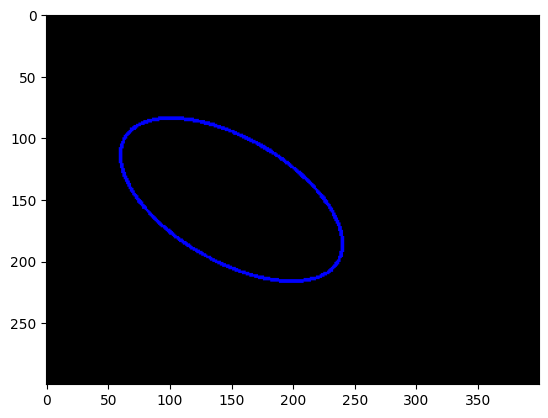

In [17]:
# Эллипс и овал
image = np.zeros((300, 400, 3), dtype=np.uint8)

center = (150, 150)
axes = (100, 50)  # Длины осей
angle = 30  # Угол поворота
start_angle = 0
end_angle = 360
color = (0, 0, 255)  
thickness = 2

cv2.ellipse(image, center, axes, angle, start_angle, end_angle, color, thickness)
plt.imshow(image)
plt.show()

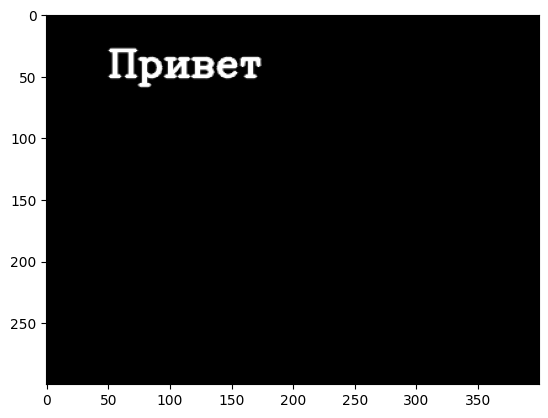

In [18]:
# Текст
image = np.zeros((300, 400, 3), dtype=np.uint8)

text = "Привет"
org = (50, 50) # Координаты нижнего левого угла текста в пикселях
font = cv2.FONT_HERSHEY_COMPLEX 
font_scale = 1
color = (255, 255, 255)  
thickness = 2

cv2.putText(image, text, org, font, font_scale, color, thickness, cv2.LINE_AA) # последний параметр - тип линии, используемый для рисования текста
plt.imshow(image)
plt.show()

видео

```python
import cv2

# Функция обработки событий мыши
def mouse_callback(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(f"Left button down at ({x}, {y})")
    elif event == cv2.EVENT_LBUTTONUP:
        print(f"Left button up at ({x}, {y})")
    elif event == cv2.EVENT_RBUTTONDOWN:
        print(f"Right button down at ({x}, {y})")
    elif event == cv2.EVENT_RBUTTONUP:
        print(f"Right button up at ({x}, {y})")
    elif event == cv2.EVENT_MBUTTONDOWN:
        print(f"Middle button down at ({x}, {y})")
    elif event == cv2.EVENT_MBUTTONUP:
        print(f"Middle button up at ({x}, {y})")
    elif event == cv2.EVENT_MOUSEMOVE:
        print(f"Mouse move at ({x}, {y})")
    elif event == cv2.EVENT_MOUSEWHEEL:
        print(f"Mouse wheel at ({x}, {y}) with flags {flags}")

# Загрузка изображения
img = cv2.imread('example.jpg')
cv2.imshow('image', img)

# Установка функции обратного вызова
cv2.setMouseCallback('image', mouse_callback)

cv2.waitKey(0)
cv2.destroyAllWindows()
```

## Поиск контуров

1. Сначала изображение переводят в grayscale:

```python
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
```

2. Затем выполняют бинаризацию:

```python
img_bin = cv2.inRange(img_gray, threshold_min, threshold_max)
```

Пиксели в выбранном диапазоне становятся белыми (`255`), остальные — чёрными (`0`).

3. После этого находят контуры:

```python
contours, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
```

- `cv2.RETR_EXTERNAL` — искать только внешние контуры;
- `cv2.CHAIN_APPROX_SIMPLE` — хранить контур компактно, без лишних точек.

4. Контуры можно нарисовать так:

```python
cv2.drawContours(img_contours, contours, -1, (0, 128, 255), 2)
```

5. Для анализа контуров часто используют площадь и периметр:

```python
area = cv2.contourArea(contour)
perimeter = cv2.arcLength(contour, True)
```

In [24]:
img = cv2.imread('../images/shapeMultiFind/093.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_bin = np.where(img_gray > 15, 255, 0).astype(np.uint8)
contours, hierarchy = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

x, y, w, h = cv2.boundingRect(contours[0]) # координаты верхнего левого угла прямоугольника + ширина и высота


## HSV

`HSV` (`Hue`, `Saturation`, `Value`) — это цветовая модель, основанная на интуитивно понятных характеристиках цвета: оттенке, насыщенности и яркости.

### H (Hue)

`H` — это оттенок цвета, то есть положение цвета на цветовом круге.

В теории цветов оттенок обычно измеряется в диапазоне от `0` до `360` градусов.

Однако в OpenCV для 8-битных изображений канал `H` хранится в диапазоне от `0` до `179`.

### S (Saturation)

`S` — это насыщенность цвета.

Значение `0` означает отсутствие насыщенности, то есть серый цвет.

Значение `255` означает максимальную насыщенность цвета.

### V (Value)

`V` — это яркость цвета.

Значение `0` соответствует чёрному цвету.

Значение `255` соответствует максимальной яркости.

## Почему HSV удобен

HSV часто используется в задачах компьютерного зрения, потому что в этом пространстве легче выделять и обрабатывать нужные цвета.

Это особенно полезно в задачах сегментации и поиска объектов по цвету, поскольку оттенок отделён от яркости.

## Яркость и контрастность изображения

Яркость и контрастность — это важные характеристики изображения, которые существенно влияют на его восприятие и качество.

Эти параметры можно изменять для улучшения видимости деталей, подготовки изображений к анализу, исправления недостатков съёмки и решения других задач.

### Яркость

**Яркость** — это общий уровень освещённости изображения.

- Увеличение яркости делает изображение светлее.
- Уменьшение яркости делает изображение темнее.

Изменение яркости выполняется путём добавления или вычитания некоторого значения ко всем пикселям изображения.

- Если добавить положительное значение, изображение станет светлее.
- Если вычесть значение, изображение станет темнее.

Например, добавление `+100` к каждому пикселю заметно осветлит изображение, а `-100` — затемнит его.

### Контрастность

**Контрастность** — это разница между самыми тёмными и самыми светлыми участками изображения.

- Высокая контрастность делает изображение более выразительным.
- Низкая контрастность делает изображение более плоским.

Изменение контрастности выполняется путём умножения значений пикселей на некоторый коэффициент.

- Если коэффициент больше `1`, контрастность увеличивается.
- Если коэффициент меньше `1`, контрастность уменьшается.

Например, умножение на `1.5` увеличивает контрастность, а умножение на `0.5` уменьшает её.

## Ограничение диапазона значений

При изменении яркости и контрастности важно следить, чтобы значения пикселей не выходили за пределы диапазона от `0` до `255`.

Для этого используется функция `np.clip()`:

```python
np.clip(image, 0, 255)
```

## Изменение яркости и контрастности в OpenCV

В OpenCV для изменения яркости и контрастности удобно использовать функцию `cv2.convertScaleAbs()`.

Она позволяет одновременно:

- умножать значения пикселей на коэффициент;
- добавлять смещение;
- автоматически ограничивать результат диапазоном `0–255`.

### Пример

```python
import cv2

# Загрузка изображения
image = cv2.imread('orig.png')

# Изменение яркости
bright_image_opencv = cv2.convertScaleAbs(image, beta=100)
dark_image_opencv = cv2.convertScaleAbs(image, beta=-100)

# Изменение контрастности
high_contrast_image_opencv = cv2.convertScaleAbs(image, alpha=1.5)
low_contrast_image_opencv = cv2.convertScaleAbs(image, alpha=0.5)
```

### Параметры функции

- `alpha` — коэффициент контрастности; на него умножается каждое значение пикселя.
- `beta` — параметр яркости; это значение добавляется к каждому пикселю после умножения.

Функция `cv2.convertScaleAbs()` выполняет эти операции и возвращает изображение с ограничением значений в диапазоне от `0` до `255`.

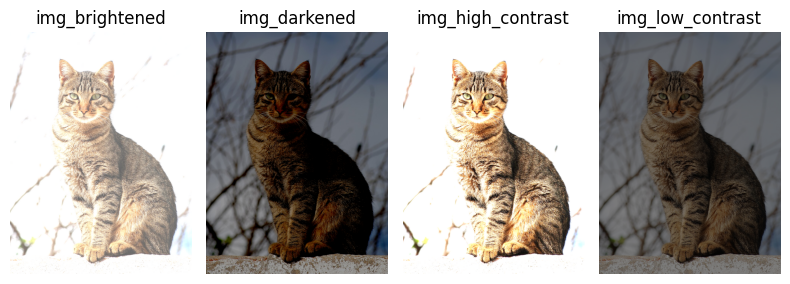

In [ ]:
image = cv2.imread('../images/Cat_November_2010-1a.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# с помощью numpy 
img_brightened = np.clip(image.astype(np.float64) + 100, 0, 255).astype(np.uint8)
img_darkened = np.clip(image.astype(np.float64) - 100, 0, 255).astype(np.uint8)
img_high_contrast = np.clip(image.astype(np.float64) * 2, 0, 255).astype(np.uint8)
img_low_contrast = np.clip(image.astype(np.float64) * 0.5, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 4, figsize=(8, 4))

axs[0].imshow(img_brightened)
axs[0].set_title("img_brightened")
axs[0].axis("off")

axs[1].imshow(img_darkened)
axs[1].set_title("img_darkened")
axs[1].axis("off")

axs[2].imshow(img_high_contrast)
axs[2].set_title("img_high_contrast")
axs[2].axis("off")

axs[3].imshow(img_low_contrast)
axs[3].set_title("img_low_contrast")
axs[3].axis("off")

plt.tight_layout()
plt.show()

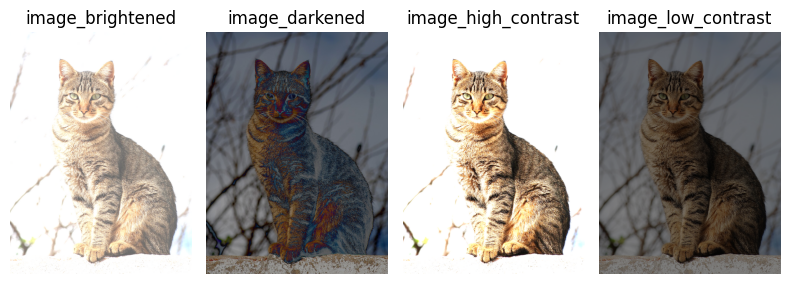

In [29]:
# с помощью opencv

image_brightened = cv2.convertScaleAbs(image, beta=100)
image_darkened = cv2.convertScaleAbs(image, beta=-100)
image_high_contrast = cv2.convertScaleAbs(image, alpha=2)
image_low_contrast = cv2.convertScaleAbs(image, alpha=0.5)

fig, axs = plt.subplots(1, 4, figsize=(8, 4))

axs[0].imshow(image_brightened)
axs[0].set_title("image_brightened")
axs[0].axis("off")

axs[1].imshow(image_darkened)
axs[1].set_title("image_darkened")
axs[1].axis("off")

axs[2].imshow(image_high_contrast)
axs[2].set_title("image_high_contrast")
axs[2].axis("off")

axs[3].imshow(image_low_contrast)
axs[3].set_title("image_low_contrast")
axs[3].axis("off")

plt.tight_layout()
plt.show()

## Масштабирование изображения

Масштабирование — это изменение размера изображения.

Оно может быть:

- **однородным** — одинаковый коэффициент по обеим осям;
- **неоднородным** — разные коэффициенты по `X` и `Y`.

## `cv2.resize()`

Основная функция для изменения размера:

```python
resized = cv2.resize(src, dsize, fx=..., fy=..., interpolation=...)
```

Параметры:

- `src` — исходное изображение;
- `dsize` — новый размер `(width, height)`;
- `fx`, `fy` — коэффициенты масштабирования;
- `interpolation` — метод интерполяции.

## Методы интерполяции

- `cv2.INTER_NEAREST` — ближайший сосед, быстро, подходит для бинарных изображений;
- `cv2.INTER_LINEAR` — билинейная интерполяция;
- `cv2.INTER_CUBIC` — более качественное увеличение;
- `cv2.INTER_LANCZOS4` — высокое качество, но медленнее.

## `cv2.pyrUp()` и `cv2.pyrDown()`

Эти функции удобны, когда нужно изменить размер изображения ровно в 2 раза:

- `cv2.pyrDown()` — уменьшает изображение в 2 раза;
- `cv2.pyrUp()` — увеличивает изображение в 2 раза.

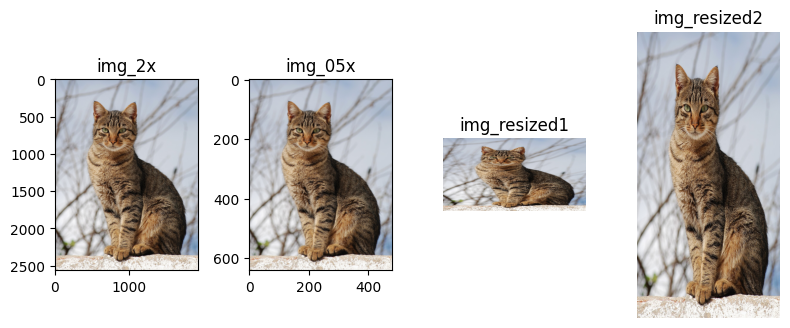

In [34]:
img_2x = cv2.pyrUp(image)
img_05x = cv2.pyrDown(image)
img_resized1 = cv2.resize(image, (500, 255))
img_resized2 = cv2.resize(image, None, fx=2, fy=3, interpolation=cv2.INTER_CUBIC)

fig, axs = plt.subplots(1, 4, figsize=(8, 4))

axs[0].imshow(img_2x)
axs[0].set_title("img_2x")

axs[1].imshow(img_05x)
axs[1].set_title("img_05x")

axs[2].imshow(img_resized1)
axs[2].set_title("img_resized1")
axs[2].axis("off")

axs[3].imshow(img_resized2)
axs[3].set_title("img_resized2")
axs[3].axis("off")

plt.tight_layout()
plt.show()

## Поворот и отражение изображения

### `cv2.rotate()`

Функция `cv2.rotate()` используется для поворота изображения на фиксированные углы:

- `cv2.ROTATE_90_CLOCKWISE` — поворот на 90° по часовой стрелке;
- `cv2.ROTATE_180` — поворот на 180°;
- `cv2.ROTATE_90_COUNTERCLOCKWISE` — поворот на 90° против часовой стрелки.

```python
rotated = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
```

### `cv2.flip()`

Функция `cv2.flip()` выполняет отражение изображения:

- `1` — по горизонтали;
- `0` — по вертикали;
- `-1` — по обеим осям.

```python
flipped = cv2.flip(image, 1)
```

## Поворот на произвольный угол

Для поворота на любой угол используют `cv2.getRotationMatrix2D()` и `cv2.warpAffine()`.

```python
(h, w) = image.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_image = cv2.warpAffine(image, M, (w, h))
```

- `center` — центр поворота;
- `45` — угол поворота;
- `1.0` — масштаб.

## Важно

При повороте на угол, отличный от `90`, `180` или `270` градусов, часть изображения может выйти за границы кадра и быть обрезана.

## Перспективное преобразование

Перспективное преобразование используется, когда нужно изменить точку зрения на изображение, например выпрямить объект или преобразовать наклонённую область в прямоугольную.

Сначала вычисляется матрица преобразования:

```python
matrix = cv2.getPerspectiveTransform(pts_src, pts_dst)
```

- `pts_src` — четыре точки на исходном изображении;
- `pts_dst` — четыре соответствующие точки на результирующем изображении.

Затем преобразование применяется к изображению:

```python
result = cv2.warpPerspective(image, matrix, (500, 500))
```

- `image` — исходное изображение;
- `matrix` — матрица преобразования;
- `(500, 500)` — размер результата.

Важно: для `cv2.getPerspectiveTransform()` нужно задать ровно 4 пары соответствующих точек.

## Размытие и фильтрация изображений

**Размытие** — это сглаживание изображения и уменьшение шума.

**Фильтрация** — это обработка изображения с помощью специальных фильтров для размытия, удаления шума, выделения контуров и других задач.

## Зачем это нужно

- уменьшение шума;
- сглаживание изображения перед дальнейшей обработкой;
- подавление мелких деталей;
- подготовка к поиску объектов и границ.

## Простое размытие

Усредняющее размытие заменяет каждый пиксель средним значением соседних пикселей.

Чем больше размер фильтра, тем сильнее размытие.

```python
blurred = cv2.blur(image, (5, 5))
```

## Гауссово размытие

Гауссово размытие тоже сглаживает изображение, но даёт больший вес пикселям около центра окна.

Оно обычно сохраняет детали лучше, чем простое усреднение.

```python
blurred = cv2.GaussianBlur(image, (5, 5), 0)
```

- чем больше размер окна, тем сильнее размытие;
- параметр `sigma` определяет степень размытия;
- если указать `0`, сигма будет выбрана автоматически.

## Медианное размытие

Медианный фильтр заменяет пиксель не средним, а медианой значений в окне.

Он особенно хорошо удаляет шум типа **соль и перец** и лучше сохраняет края.

```python
blurred = cv2.medianBlur(image, 5)
```

Примеры:

- `cv2.medianBlur(image, 3)` — слабое размытие;
- `cv2.medianBlur(image, 5)` — умеренное размытие;
- `cv2.medianBlur(image, 15)` — сильное размытие.

## Билатеральное фильтрование

Билатеральный фильтр используется для сглаживания изображения и уменьшения шума с сохранением краёв.

В отличие от обычного размытия, он учитывает:

- расстояние между пикселями;
- различие их интенсивностей.

Поэтому шум уменьшается, а границы объектов остаются более чёткими.

## Параметры

- `d` — размер окна фильтра;
- `sigmaColor` — чувствительность к различию интенсивностей;
- `sigmaSpace` — влияние расстояния между пикселями.

Чем больше значения параметров, тем сильнее сглаживание.

## Плюсы и минусы

**Преимущества:**

- хорошо убирает шум;
- сохраняет края;
- гибко настраивается.

**Недостатки:**

- работает медленнее многих других фильтров;
- чувствителен к выбору параметров.

## Фильтры выделения контуров

Для выделения границ часто используют фильтры **Собеля** и **Лапласа**.

### Собель

Фильтр Собеля вычисляет градиенты изображения:

- по `X` — выделяет вертикальные края;
- по `Y` — выделяет горизонтальные края.

```python
sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
```

### Лаплас

Фильтр Лапласа выделяет края во всех направлениях.

```python
laplacian = cv2.Laplacian(image, cv2.CV_64F)
```

После этого результат часто переводят в удобный формат:

```python
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)
laplacian_abs = cv2.convertScaleAbs(laplacian)
```

## Главное

- **Билатеральный фильтр** — сглаживание с сохранением краёв.
- **Собель** — поиск границ по направлениям `X` и `Y`.
- **Лаплас** — поиск резких изменений яркости во всех направлениях.

## Морфологические операции

Морфологические операции используются для обработки формы объектов на бинарных или полутоновых изображениях.

Основные операции:

- `dilate` — расширение светлых областей;
- `erode` — сжатие светлых областей.

Для работы используется **ядро**:

```python
kernel = np.ones((5, 5), np.uint8)
```

## Эрозия

Эрозия уменьшает белые объекты и убирает мелкий белый шум.

```python
eroded_image = cv2.erode(image, kernel, iterations=1)
```

Чем больше `iterations`, тем сильнее сжатие.

## Дилатация

Дилатация увеличивает белые объекты и убирает мелкие чёрные отверстия внутри них.

```python
dilated_image = cv2.dilate(image, kernel, iterations=1)
```

Чем больше `iterations`, тем сильнее расширение.

## Открытие и закрытие

**Открытие** = эрозия + дилатация.  
Используется для удаления мелкого белого шума.

```python
opened_image = cv2.morphologyEx(noisy_image, cv2.MORPH_OPEN, kernel)
```

**Закрытие** = дилатация + эрозия.  
Используется для удаления мелких чёрных дыр и разрывов.

```python
closed_image = cv2.morphologyEx(noisy_image, cv2.MORPH_CLOSE, kernel)
```

## Градиент

Морфологический градиент показывает контуры объектов как разницу между дилатацией и эрозией.

```python
gradient_image = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)
```

## Главное

- `erode` — убирает мелкие белые шумы;
- `dilate` — убирает мелкие чёрные шумы;
- `opening` — очищает изображение от белого шума;
- `closing` — заполняет мелкие пробелы внутри объектов;
- `gradient` — выделяет контуры.

## Структурный элемент (ядро)

**Структурный элемент** или **ядро** — это небольшая матрица, которая задаёт форму и размер области для морфологической операции.

Именно ядро определяет, как будут работать `erode()` и `dilate()`.

Например:

```python
kernel = np.ones((5, 5), np.uint8)
```

Это квадратное ядро размером `5 x 5`, заполненное единицами.

## Зачем нужно ядро

Ядро перемещается по изображению и определяет, какие соседние пиксели участвуют в обработке.

От его **размера** и **формы** зависит результат:

- большее ядро — сильнее эффект;
- меньшее ядро — слабее эффект.

## Формы ядер

### Прямоугольное

```python
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
```

Подходит для простых объектов и общего удаления шума.

### Эллиптическое

```python
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
```

Лучше подходит для округлых объектов и более плавной обработки контуров.

### Крестовидное

```python
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
```

Используется в более специальных случаях, когда важна обработка по вертикали и горизонтали.

## Главное

- ядро задаёт область обработки;
- форма ядра влияет на результат;
- размер ядра определяет силу морфологической операции;
- ядро можно создавать как обычный массив или через `cv2.getStructuringElement()`.

## Matching изображений

**Matching** — это поиск соответствующих точек на двух похожих изображениях.

Общая идея такая:

изображение → ключевые точки → дескрипторы → сравнение → хорошие совпадения → визуализация

## Ключевые точки

**Ключевая точка** — это заметное место на изображении, которое можно узнать повторно.

Хорошие ключевые точки:
- углы;
- пересечения линий;
- контрастные текстуры;
- выраженные локальные детали.

Плохие области:
- однотонное небо;
- гладкая стена;
- размытые участки без деталей.

## Дескриптор

Одних координат точки недостаточно.

Поэтому для каждой ключевой точки строят **дескриптор** — числовое описание области вокруг неё.

Полезно запомнить так:

- **keypoint** — где находится точка;
- **descriptor** — как выглядит область вокруг неё.

## ORB и SIFT

### ORB
- быстрее;
- проще для старта;
- хорошо подходит для базовой практики.

### SIFT
- медленнее;
- обычно устойчивее;
- часто даёт более качественные совпадения.

Коротко:

- **ORB** — быстрее;
- **SIFT** — надёжнее, но тяжелее.

## Matching

После нахождения дескрипторов нужно понять, какие точки соответствуют друг другу.

Это и есть **matching**.

Хороший match:
- соединяет один и тот же объект;
- выглядит логично;
- не создаёт визуального хаоса.

Плохой match:
- соединяет случайные детали;
- попадает в фон;
- даёт много мусорных линий.

## Базовый конвейер

1. Прочитать два изображения.
2. Перевести их в grayscale.
3. Найти keypoints и descriptors.
4. Сопоставить descriptors.
5. Оставить лучшие matches.
6. Нарисовать результат.

## ORB: базовый пример

```python
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('img1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2.jpg', cv2.IMREAD_GRAYSCALE)

orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

if des1 is None or des2 is None:
    print("Не удалось найти дескрипторы")
else:
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    result = cv2.drawMatches(
        img1, kp1, img2, kp2, matches[:30], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(14, 7))
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    plt.show()
```

## SIFT: базовый пример

```python
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('img1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2.jpg', cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

if des1 is None or des2 is None:
    print("Не удалось найти дескрипторы")
else:
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    result = cv2.drawMatches(
        img1, kp1, img2, kp2, matches[:30], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(14, 7))
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    plt.show()
```

## Важное различие

- для **ORB** используют `cv2.NORM_HAMMING`;
- для **SIFT** используют `cv2.NORM_L2`.

## Ratio test

Более аккуратный способ фильтрации совпадений — **ratio test**.

Идея:

- ищем два лучших кандидата;
- если лучший заметно лучше второго, оставляем;
- если они слишком похожи, совпадение считаем сомнительным.

```python
bf = cv2.BFMatcher(cv2.NORM_L2)
raw_matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in raw_matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)
```

## Частые ошибки

1. Неправильная метрика:
   - ORB → `NORM_HAMMING`
   - SIFT → `NORM_L2`

2. `des1` или `des2` равны `None`:
   - значит точки или дескрипторы не нашлись.

3. Слишком разные изображения:
   - совпадения будут плохими.

4. Слишком много линий на визуализации:
   - лучше показывать лучшие `20–50` matches.

## Главное

- **Keypoints** — заметные точки.
- **Descriptors** — числовое описание этих точек.
- **Matching** — поиск похожих дескрипторов между двумя изображениями.
- **drawMatches** — визуальный показ найденных совпадений.